In [1]:
invested = {
    "Nasdaq": 5100,
    "Emergenti": 4110,
    "Stock600EU": 3850,
    "SP500": 3181,
    "Oro": 14722,
    "Robot": 1336,
    "Amazon": 1000
}

In [2]:
import pandas as pd
import numpy as np

# ============================================================
# 1) FILE E IMPORTI INVESTITI
# ============================================================

files = {
    "Nasdaq": r"/Users/riccardocornelli/Desktop/portafogli_fondamentali/nasdaq.xlsx",
    "Emergenti": r"/Users/riccardocornelli/Desktop/portafogli_fondamentali/emergenti.xlsx",
    "Stock600EU": r"/Users/riccardocornelli/Desktop/portafogli_fondamentali/stock600eu.xlsx",
    "SP500": r"/Users/riccardocornelli/Desktop/portafogli_fondamentali/sp500.xlsx",
    "Oro": r"/Users/riccardocornelli/Desktop/portafogli_fondamentali/ORO.xlsx",
    "Robot": r"/Users/riccardocornelli/Desktop/portafogli_fondamentali/ROBOT.xlsx",
    "Amazon": r"/Users/riccardocornelli/Desktop/portafogli_fondamentali/AMAZON.xlsx"
}

invested = {
    "Nasdaq": 10300,
    "Emergenti": 9110,
    "Stock600EU": 6850,
    "SP500": 4680,
    "Oro": 1500,
    "Robot": 1336,
    "Amazon": 1000
}

portfolio_value = sum(invested.values())
weights = pd.Series(invested) / portfolio_value

# ============================================================
# 2) LETTURA FILE
#    Assunzione: colonna 1 = Date, colonna 2 = return
# ============================================================

series_list = []

for name, path in files.items():
    df = pd.read_excel(path)
    df = df.iloc[:, :2].copy()
    df.columns = ["Date", name]

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[name] = pd.to_numeric(df[name], errors="coerce")
    df = df.dropna(subset=["Date", name]).sort_values("Date")

    series_list.append(df)

# Merge sulle date comuni
returns_df = series_list[0]
for df in series_list[1:]:
    returns_df = returns_df.merge(df, on="Date", how="inner")

returns_df = returns_df.sort_values("Date").reset_index(drop=True)

asset_cols = list(files.keys())

# ============================================================
# 3) CONTROLLO FORMATO RETURNS
#    Se sembrano percentuali tipo 1.2 o -0.8, li converte in decimali
# ============================================================

for col in asset_cols:
    if returns_df[col].abs().median() > 0.2:
        returns_df[col] = returns_df[col] / 100

# ============================================================
# 4) IMPOSTA DATE COME INDEX
# ============================================================

returns_df = returns_df.set_index("Date")

# ============================================================
# 5) RENDIMENTO GIORNALIERO DEL PORTAFOGLIO
# ============================================================

returns_df["Portfolio_Return"] = returns_df[asset_cols].mul(weights, axis=1).sum(axis=1)

# ============================================================
# 6) FUNZIONI
# ============================================================

def historical_var(returns, alpha=0.95):
    returns = pd.Series(returns).dropna()
    q = np.quantile(returns, 1 - alpha)
    return -q

def historical_cvar(returns, alpha=0.95):
    returns = pd.Series(returns).dropna()
    q = np.quantile(returns, 1 - alpha)
    tail = returns[returns <= q]
    return -tail.mean()

def compound_returns(series, freq):
    """
    Compone i rendimenti per periodo:
    freq='M' -> mensile
    freq='Y' -> annuale
    """
    series = pd.Series(series).dropna()
    return series.groupby(pd.Grouper(freq=freq)).apply(lambda x: (1 + x).prod() - 1)

def build_risk_row(name, returns, base_value=None):
    returns = pd.Series(returns).dropna()
    row = {
        "Serie": name,
        "N_obs": len(returns),
        "VaR_95": historical_var(returns, 0.95),
        "CVaR_95": historical_cvar(returns, 0.95),
        "VaR_99": historical_var(returns, 0.99),
        "CVaR_99": historical_cvar(returns, 0.99),
    }
    if base_value is not None:
        row["VaR_95_EUR"] = row["VaR_95"] * base_value
        row["CVaR_95_EUR"] = row["CVaR_95"] * base_value
        row["VaR_99_EUR"] = row["VaR_99"] * base_value
        row["CVaR_99_EUR"] = row["CVaR_99"] * base_value
    return row

# ============================================================
# 7) CORRELAZIONI
# ============================================================

corr_daily = returns_df[asset_cols].corr()

monthly_assets = returns_df[asset_cols].groupby(pd.Grouper(freq="M")).apply(lambda x: (1 + x).prod() - 1)
yearly_assets  = returns_df[asset_cols].groupby(pd.Grouper(freq="Y")).apply(lambda x: (1 + x).prod() - 1)

corr_monthly = monthly_assets.corr()
corr_yearly = yearly_assets.corr()

# ============================================================
# 8) RENDIMENTI PORTAFOGLIO A DIVERSI ORIZZONTI
# ============================================================

port_daily = returns_df["Portfolio_Return"].dropna()
port_monthly = compound_returns(port_daily, "M")
port_yearly = compound_returns(port_daily, "Y")

# ============================================================
# 9) VAR / CVAR DEL PORTAFOGLIO
# ============================================================

portfolio_risk = pd.DataFrame([
    build_risk_row("Portafoglio_Giornaliero", port_daily, portfolio_value),
    build_risk_row("Portafoglio_Mensile", port_monthly, portfolio_value),
    build_risk_row("Portafoglio_Annuale", port_yearly, portfolio_value),
])

# ============================================================
# 10) VAR / CVAR DEI SINGOLI ASSET PER FREQUENZA
# ============================================================

asset_risk_daily = pd.DataFrame([
    build_risk_row(col, returns_df[col].dropna())
    for col in asset_cols
])

asset_risk_monthly = pd.DataFrame([
    build_risk_row(col, compound_returns(returns_df[col], "M"))
    for col in asset_cols
])

asset_risk_yearly = pd.DataFrame([
    build_risk_row(col, compound_returns(returns_df[col], "Y"))
    for col in asset_cols
])

# ============================================================
# 11) STAMPA OUTPUT
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("\n" + "="*90)
print("PESI DEL PORTAFOGLIO")
print("="*90)
print(weights.round(4))

print("\n" + "="*90)
print("CORRELAZIONE GIORNALIERA")
print("="*90)
print(corr_daily.round(4))

print("\n" + "="*90)
print("CORRELAZIONE MENSILE")
print("="*90)
print(corr_monthly.round(4))

print("\n" + "="*90)
print("CORRELAZIONE ANNUALE")
print("="*90)
print(corr_yearly.round(4))

print("\n" + "="*90)
print("VAR / CVAR DEL PORTAFOGLIO")
print("="*90)
print(portfolio_risk.round(4))

print("\n" + "="*90)
print("VAR / CVAR DEI SINGOLI ASSET - GIORNALIERO")
print("="*90)
print(asset_risk_daily.round(4))

print("\n" + "="*90)
print("VAR / CVAR DEI SINGOLI ASSET - MENSILE")
print("="*90)
print(asset_risk_monthly.round(4))

print("\n" + "="*90)
print("VAR / CVAR DEI SINGOLI ASSET - ANNUALE")
print("="*90)
print(asset_risk_yearly.round(4))

print("\n" + "="*90)
print("ANTEPRIMA RENDIMENTI PORTAFOGLIO")
print("="*90)
preview = pd.DataFrame({
    "Port_Daily": port_daily.head(),
    "Port_Monthly": port_monthly.head(),
    "Port_Yearly": port_yearly.head()
})
print(preview)


PESI DEL PORTAFOGLIO
Nasdaq        0.2962
Emergenti     0.2620
Stock600EU    0.1970
SP500         0.1346
Oro           0.0431
Robot         0.0384
Amazon        0.0288
dtype: float64

CORRELAZIONE GIORNALIERA
            Nasdaq  Emergenti  Stock600EU   SP500     Oro   Robot  Amazon
Nasdaq      1.0000     0.6573      0.7205  0.9187  0.0083  0.8550  0.4095
Emergenti   0.6573     1.0000      0.7429  0.6846  0.1072  0.7513  0.2929
Stock600EU  0.7205     0.7429      1.0000  0.8326  0.0267  0.7848  0.2379
SP500       0.9187     0.6846      0.8326  1.0000 -0.0086  0.8513  0.3094
Oro         0.0083     0.1072      0.0267 -0.0086  1.0000  0.0475  0.0224
Robot       0.8550     0.7513      0.7848  0.8513  0.0475  1.0000  0.3891
Amazon      0.4095     0.2929      0.2379  0.3094  0.0224  0.3891  1.0000

CORRELAZIONE MENSILE
            Nasdaq  Emergenti  Stock600EU   SP500     Oro   Robot  Amazon
Nasdaq      1.0000     0.6040      0.6462  0.9138  0.0146  0.8465  0.7558
Emergenti   0.6040     1.000

/var/folders/c1/k9bvx70n1t5fd9y8hsjp28780000gn/T/ipykernel_38271/3972099109.py:126: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_assets = returns_df[asset_cols].groupby(pd.Grouper(freq="M")).apply(lambda x: (1 + x).prod() - 1)
/var/folders/c1/k9bvx70n1t5fd9y8hsjp28780000gn/T/ipykernel_38271/3972099109.py:127: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_assets  = returns_df[asset_cols].groupby(pd.Grouper(freq="Y")).apply(lambda x: (1 + x).prod() - 1)
/var/folders/c1/k9bvx70n1t5fd9y8hsjp28780000gn/T/ipykernel_38271/3972099109.py:101: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return series.groupby(pd.Grouper(freq=freq)).apply(lambda x: (1 + x).prod() - 1)
/var/folders/c1/k9bvx70n1t5fd9y8hsjp28780000gn/T/ipykernel_38271/3972099109.py:101: FutureWarning: 'Y' is deprecated and will be removed in a future ver

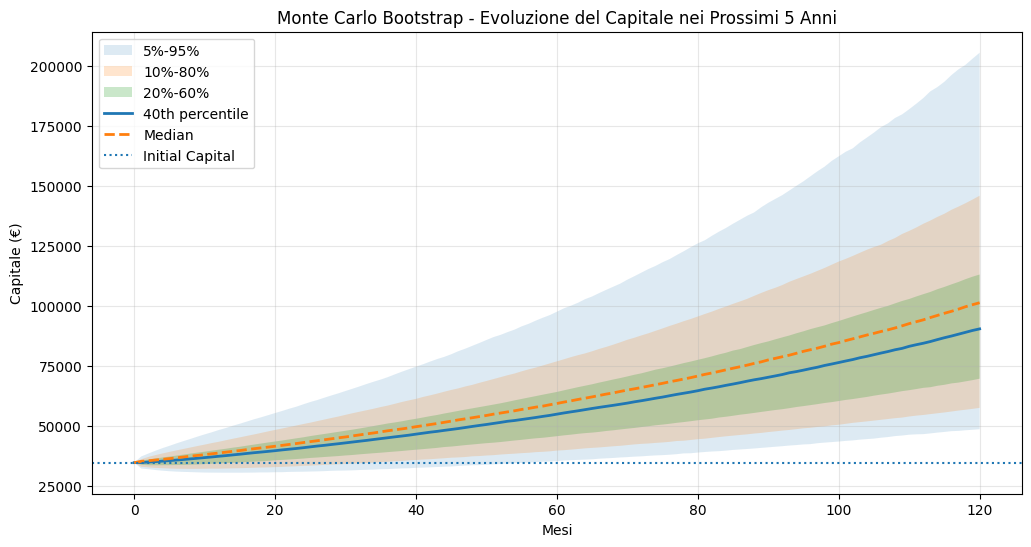

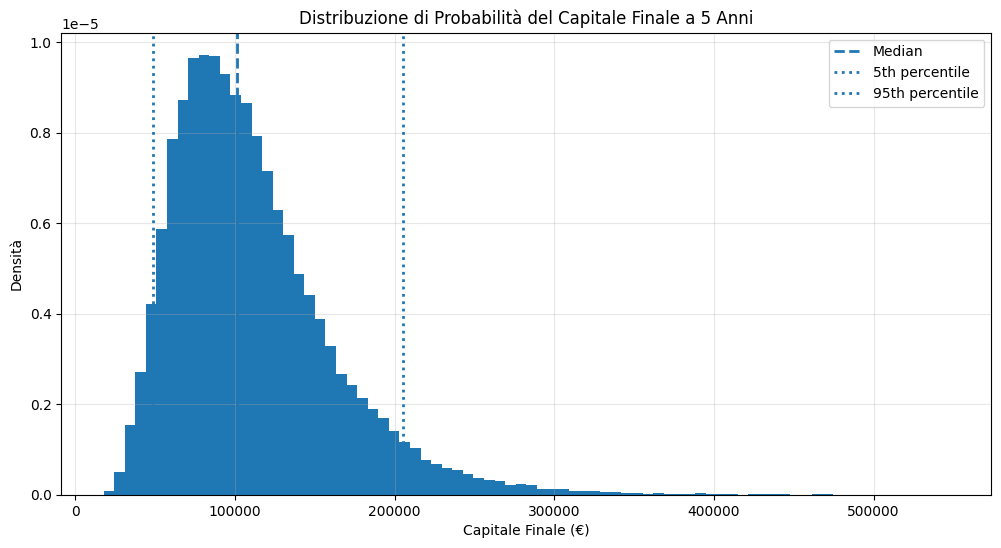


MONTE CARLO BOOTSTRAP - SUMMARY
                                Metric      Value
0                      Initial Capital  34,776.00
1                   Mean Final Capital 110,833.93
2                 Median Final Capital 101,321.48
3                    Min Final Capital  17,684.52
4                    Max Final Capital 547,298.12
5  Probability Final Capital > Initial      99.14
6  Probability Final Capital < Initial       0.86

PERCENTILI DEL CAPITALE FINALE A 5 ANNI
   Percentile  Final_Capital_EUR
0           5          48,692.85
1          10          57,561.78
2          20          69,714.44
3          40          90,441.72
4          60         113,056.83
5          80         145,853.64
6          95         205,345.08

SCAGLIONI DI PROBABILITÀ DEL CAPITALE FINALE
       Range  Probability_%
0  Bottom 5%           5.00
1   5% - 10%           5.00
2  10% - 20%          10.00
3  20% - 40%          20.00
4  40% - 60%          20.00
5  60% - 80%          20.00
6  80% - 95%        

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) PARAMETRI MONTE CARLO
# ============================================================

n_simulations = 50000
n_months = 120   # 10 anni
initial_capital = portfolio_value

# Usa i rendimenti mensili storici del portafoglio
historical_monthly_returns = port_monthly.dropna().values



# ============================================================
# 2) MONTE CARLO BOOTSTRAP
#    Ogni mese estrae casualmente un rendimento mensile storico
# ============================================================

simulated_paths = np.zeros((n_simulations, n_months + 1))
simulated_paths[:, 0] = initial_capital

for i in range(n_simulations):
    sampled_returns = np.random.choice(historical_monthly_returns, size=n_months, replace=True)
    capital_path = initial_capital * np.cumprod(1 + sampled_returns)
    simulated_paths[i, 1:] = capital_path

final_capitals = simulated_paths[:, -1]

# ============================================================
# 3) PERCENTILI DEL CAPITALE FINALE
# ============================================================

percentile_levels = [5, 10, 20, 40, 60, 80, 95]
percentile_values = np.percentile(final_capitals, percentile_levels)

percentiles_table = pd.DataFrame({
    "Percentile": percentile_levels,
    "Final_Capital_EUR": percentile_values
})

# ============================================================
# 4) SCAGLIONI DI PROBABILITÀ
#    bottom 5%, 5-10%, 10-20%, 20-40%, 40-60%, 60-80%, 80-95%, top 5%
# ============================================================

p5, p10, p20, p40, p60, p80, p95 = percentile_values

bins = [-np.inf, p5, p10, p20, p40, p60, p80, p95, np.inf]
labels = [
    "Bottom 5%",
    "5% - 10%",
    "10% - 20%",
    "20% - 40%",
    "40% - 60%",
    "60% - 80%",
    "80% - 95%",
    "Top 5%"
]

bucket_series = pd.Series(pd.cut(final_capitals, bins=bins, labels=labels, include_lowest=True))
bucket_distribution = (bucket_series.value_counts() / len(bucket_series)).sort_index() * 100

bucket_table = pd.DataFrame({
    "Range": bucket_distribution.index,
    "Probability_%": bucket_distribution.values
})

# ============================================================
# 5) ALTRE METRICHE UTILI
# ============================================================

summary_table = pd.DataFrame({
    "Metric": [
        "Initial Capital",
        "Mean Final Capital",
        "Median Final Capital",
        "Min Final Capital",
        "Max Final Capital",
        "Probability Final Capital > Initial",
        "Probability Final Capital < Initial"
    ],
    "Value": [
        initial_capital,
        final_capitals.mean(),
        np.median(final_capitals),
        final_capitals.min(),
        final_capitals.max(),
        (final_capitals > initial_capital).mean() * 100,
        (final_capitals < initial_capital).mean() * 100
    ]
})

# ============================================================
# 6) FAN CHART DEI PERCENTILI NEL TEMPO
# ============================================================

path_percentiles = [5, 10, 20, 40, 60, 80, 95]
fan = np.percentile(simulated_paths, path_percentiles, axis=0)

months_axis = np.arange(0, n_months + 1)

plt.figure(figsize=(12, 6))
plt.fill_between(months_axis, fan[0], fan[-1], alpha=0.15, label="5%-95%")
plt.fill_between(months_axis, fan[1], fan[-2], alpha=0.20, label="10%-80%")
plt.fill_between(months_axis, fan[2], fan[-3], alpha=0.25, label="20%-60%")
plt.plot(months_axis, fan[3], linewidth=2, label="40th percentile")
plt.plot(months_axis, np.percentile(simulated_paths, 50, axis=0), linewidth=2, linestyle="--", label="Median")
plt.axhline(initial_capital, linestyle=":", linewidth=1.5, label="Initial Capital")
plt.title("Monte Carlo Bootstrap - Evoluzione del Capitale nei Prossimi 5 Anni")
plt.xlabel("Mesi")
plt.ylabel("Capitale (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# 7) DISTRIBUZIONE DEL CAPITALE FINALE
# ============================================================

plt.figure(figsize=(12, 6))
plt.hist(final_capitals, bins=80, density=True)
plt.axvline(np.median(final_capitals), linestyle="--", linewidth=2, label="Median")
plt.axvline(p5, linestyle=":", linewidth=2, label="5th percentile")
plt.axvline(p95, linestyle=":", linewidth=2, label="95th percentile")
plt.title("Distribuzione di Probabilità del Capitale Finale a 5 Anni")
plt.xlabel("Capitale Finale (€)")
plt.ylabel("Densità")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# 8) STAMPA RISULTATI
# ============================================================

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("\n" + "="*90)
print("MONTE CARLO BOOTSTRAP - SUMMARY")
print("="*90)
print(summary_table)

print("\n" + "="*90)
print("PERCENTILI DEL CAPITALE FINALE A 5 ANNI")
print("="*90)
print(percentiles_table)

print("\n" + "="*90)
print("SCAGLIONI DI PROBABILITÀ DEL CAPITALE FINALE")
print("="*90)
print(bucket_table)


PERFORMANCE REALE DEL PORTAFOGLIO - METRICHE MENSILI
                    Metric        Value
0          Initial Capital  34,776.0000
1            Final Capital  77,096.4612
2             Total Return       1.2169
3      Mean Monthly Return       0.0097
4    Median Monthly Return       0.0159
5       Monthly Volatility       0.0401
6    Monthly Sharpe (rf=0)       0.2415
7   Monthly Sortino (rf=0)       0.3677
8          Positive Months           56
9          Negative Months           34
10             Flat Months            0
11               Hit Ratio       0.6222
12       Best Month Return       0.0997
13         Best Month Date      2020-04
14      Worst Month Return      -0.0900
15        Worst Month Date      2020-03

DRAWDOWN ANALYSIS
               Metric        Value
0        Max Drawdown      -0.2211
1  Peak Before Max DD      2021-12
2    Trough of Max DD      2022-12
3     Capital at Peak  55,937.2614
4   Capital at Trough  43,570.4921
5       Recovery Date      2024-02
6 

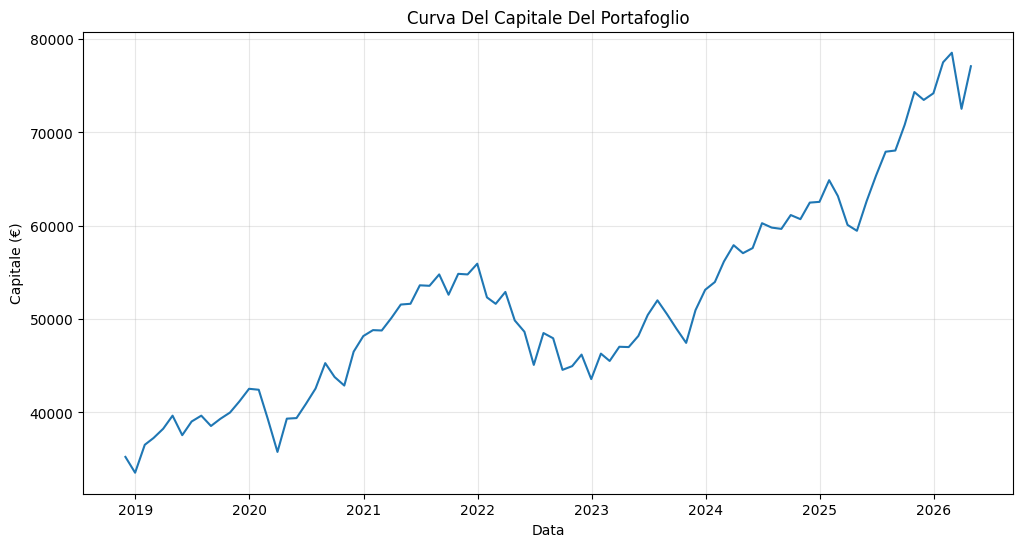

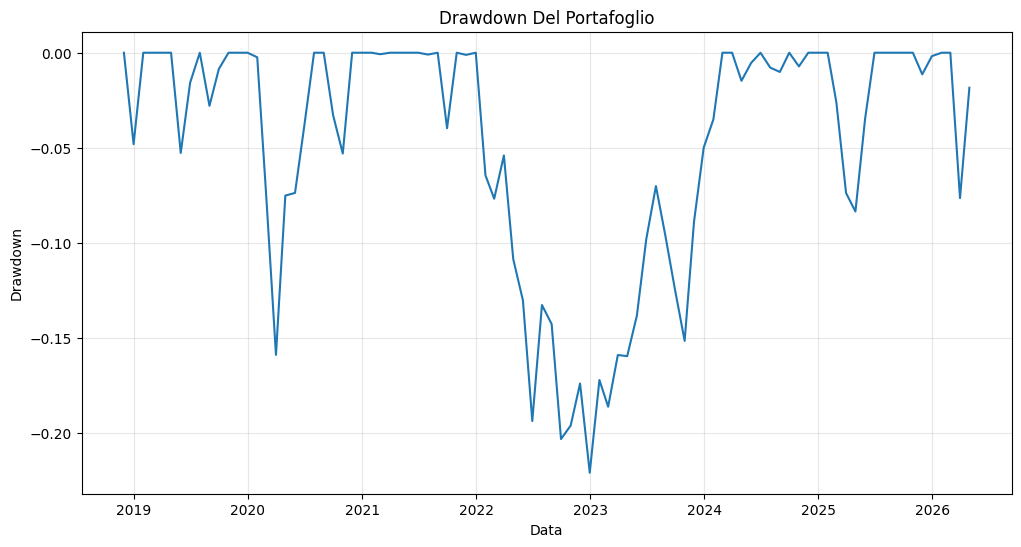

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) PREPARAZIONE DATI
#    Usa metriche MENSILI, non annualizzate
# ============================================================

# Se port_monthly non esiste, lo costruisce da port_daily

monthly_returns = pd.Series(port_monthly).dropna().copy()
monthly_returns.name = "Portfolio_Monthly_Return"



initial_capital = float(portfolio_value)

# ============================================================
# 2) CURVA DEL CAPITALE
# ============================================================

capital_curve = initial_capital * (1 + monthly_returns).cumprod()
capital_curve.name = "Capital"

running_peak = capital_curve.cummax()
drawdown = capital_curve / running_peak - 1
drawdown.name = "Drawdown"

# ============================================================
# 3) METRICHE PERFORMANCE REALI
# ============================================================

total_return = capital_curve.iloc[-1] / initial_capital - 1
mean_monthly_return = monthly_returns.mean()
median_monthly_return = monthly_returns.median()
monthly_volatility = monthly_returns.std(ddof=1)

# Sharpe mensile con rf mensile = 0
risk_free_monthly = 0.0
sharpe_monthly = (
    (mean_monthly_return - risk_free_monthly) / monthly_volatility
    if monthly_volatility != 0 else np.nan
)

downside_returns = monthly_returns[monthly_returns < risk_free_monthly]
downside_deviation = downside_returns.std(ddof=1) if len(downside_returns) > 1 else np.nan
sortino_monthly = (
    (mean_monthly_return - risk_free_monthly) / downside_deviation
    if pd.notna(downside_deviation) and downside_deviation != 0 else np.nan
)

positive_months = (monthly_returns > 0).sum()
negative_months = (monthly_returns < 0).sum()
flat_months = (monthly_returns == 0).sum()
hit_ratio = (monthly_returns > 0).mean()

best_month = monthly_returns.max()
worst_month = monthly_returns.min()
best_month_date = monthly_returns.idxmax()
worst_month_date = monthly_returns.idxmin()

# ============================================================
# 4) DRAWDOWN ANALYSIS
# ============================================================

max_drawdown = drawdown.min()
max_dd_trough_date = drawdown.idxmin()

# Data del picco che precede il max drawdown
peak_before_trough_date = capital_curve.loc[:max_dd_trough_date].idxmax()
peak_before_trough_value = capital_curve.loc[peak_before_trough_date]
trough_value = capital_curve.loc[max_dd_trough_date]

# Recovery del max drawdown: prima data in cui il capitale torna >= al vecchio picco
recovery_candidates = capital_curve.loc[capital_curve.index > max_dd_trough_date]
recovery_candidates = recovery_candidates[recovery_candidates >= peak_before_trough_value]

if len(recovery_candidates) > 0:
    recovery_date = recovery_candidates.index[0]
    recovery_months = (recovery_date.to_period("M") - peak_before_trough_date.to_period("M")).n
else:
    recovery_date = pd.NaT
    recovery_months = np.nan

current_drawdown = drawdown.iloc[-1]
average_drawdown = drawdown[drawdown < 0].mean() if (drawdown < 0).any() else 0.0

# ============================================================
# 5) DURATA DEI DRAWDOWN
# ============================================================

drawdown_flag = drawdown < 0
durations = []
start_date = None
duration = 0

for date, is_dd in drawdown_flag.items():
    if is_dd:
        if start_date is None:
            start_date = date
            duration = 1
        else:
            duration += 1
    else:
        if start_date is not None:
            durations.append({
                "Start": start_date,
                "End": date,
                "Duration_Months": duration
            })
            start_date = None
            duration = 0

# Se ultimo periodo è ancora in drawdown
durations_df = pd.DataFrame(durations)



# ============================================================
# 6) TABELLE RIASSUNTIVE
# ============================================================

performance_summary = pd.DataFrame({
    "Metric": [
        "Initial Capital",
        "Final Capital",
        "Total Return",
        "Mean Monthly Return",
        "Median Monthly Return",
        "Monthly Volatility",
        "Monthly Sharpe (rf=0)",
        "Monthly Sortino (rf=0)",
        "Positive Months",
        "Negative Months",
        "Flat Months",
        "Hit Ratio",
        "Best Month Return",
        "Best Month Date",
        "Worst Month Return",
        "Worst Month Date"
    ],
    "Value": [
        initial_capital,
        capital_curve.iloc[-1],
        total_return,
        mean_monthly_return,
        median_monthly_return,
        monthly_volatility,
        sharpe_monthly,
        sortino_monthly,
        positive_months,
        negative_months,
        flat_months,
        hit_ratio,
        best_month,
        best_month_date.strftime("%Y-%m"),
        worst_month,
        worst_month_date.strftime("%Y-%m")
    ]
})

drawdown_summary = pd.DataFrame({
    "Metric": [
        "Max Drawdown",
        "Peak Before Max DD",
        "Trough of Max DD",
        "Capital at Peak",
        "Capital at Trough",
        "Recovery Date",
        "Recovery Months",
        "Current Drawdown",
        "Average Drawdown"
    ],
    "Value": [
        max_drawdown,
        peak_before_trough_date.strftime("%Y-%m"),
        max_dd_trough_date.strftime("%Y-%m"),
        peak_before_trough_value,
        trough_value,
        recovery_date.strftime("%Y-%m") if pd.notna(recovery_date) else "Not recovered yet",
        recovery_months,
        current_drawdown,
        average_drawdown
    ]
})

worst_months_table = (
    monthly_returns.sort_values()
    .head(10)
    .reset_index()
)
worst_months_table.columns = ["Date", "Monthly_Return"]
worst_months_table["Date"] = worst_months_table["Date"].dt.strftime("%Y-%m")

best_months_table = (
    monthly_returns.sort_values(ascending=False)
    .head(10)
    .reset_index()
)
best_months_table.columns = ["Date", "Monthly_Return"]
best_months_table["Date"] = best_months_table["Date"].dt.strftime("%Y-%m")

# ============================================================
# 7) FORMATTAZIONE STAMPA
# ============================================================

def fmt_value(x):
    if isinstance(x, (int, np.integer)):
        return f"{x}"
    if isinstance(x, (float, np.floating)):
        return f"{x:,.4f}"
    return x

print("\n" + "="*95)
print("PERFORMANCE REALE DEL PORTAFOGLIO - METRICHE MENSILI")
print("="*95)
print(performance_summary.map(fmt_value))

print("\n" + "="*95)
print("DRAWDOWN ANALYSIS")
print("="*95)
print(drawdown_summary.map(fmt_value))

print("\n" + "="*95)
print("10 PEGGIORI MESI")
print("="*95)
print(worst_months_table.assign(Monthly_Return=worst_months_table["Monthly_Return"].map(lambda x: f"{x:.4%}")))

print("\n" + "="*95)
print("10 MIGLIORI MESI")
print("="*95)
print(best_months_table.assign(Monthly_Return=best_months_table["Monthly_Return"].map(lambda x: f"{x:.4%}")))

# ============================================================
# 8) GRAFICO CURVA DEL CAPITALE
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(capital_curve.index, capital_curve.values)
plt.title("Curva Del Capitale Del Portafoglio")
plt.xlabel("Data")
plt.ylabel("Capitale (€)")
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# 9) GRAFICO DRAWDOWN
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(drawdown.index, drawdown.values)
plt.title("Drawdown Del Portafoglio")
plt.xlabel("Data")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()

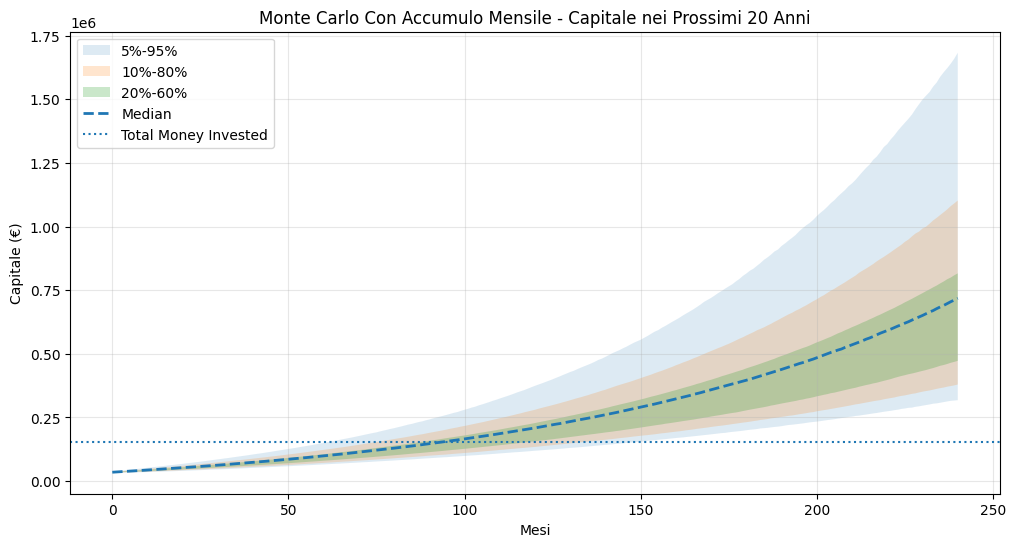

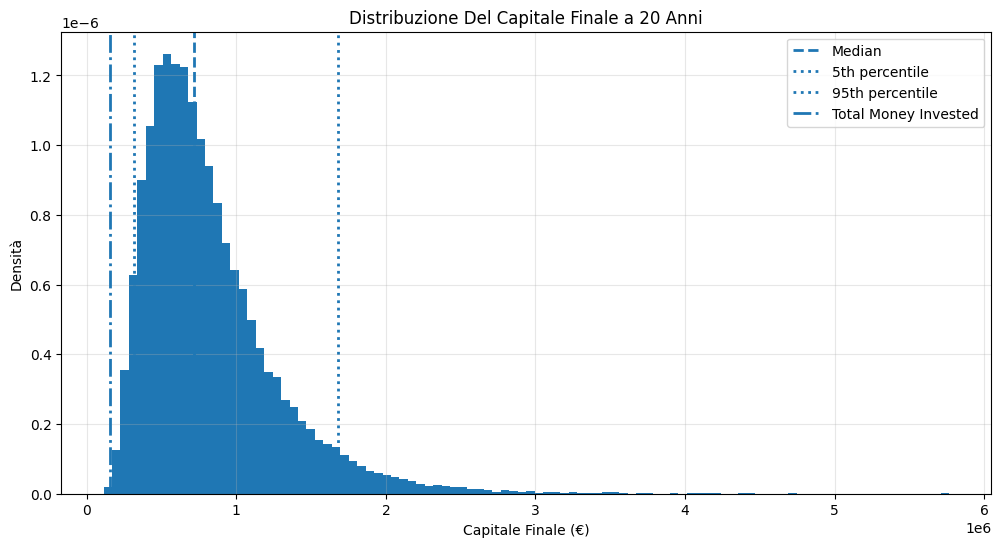


MONTE CARLO CON ACCUMULO MENSILE - SUMMARY
                                              Metric        Value
0                                    Initial Capital    34,776.00
1                               Monthly Contribution       500.00
2                                              Years        20.00
3                           Total Contributions Only   120,000.00
4                               Total Money Invested   154,776.00
5                                 Mean Final Capital   822,580.00
6                               Median Final Capital   718,143.96
7                                  Min Final Capital   111,775.83
8                                  Max Final Capital 5,765,592.76
9   Probability Final Capital > Total Money Invested        99.96
10  Probability Final Capital < Total Money Invested         0.04

PERCENTILI DEL CAPITALE FINALE A 20 ANNI
   Percentile  Final_Capital_EUR
0           5         317,709.19
1          10         379,247.06
2          20         4

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) PARAMETRI
# ============================================================

n_simulations = 50000
n_years = 20
n_months = n_years * 12
monthly_contribution = 500
initial_capital = float(portfolio_value)

# Rendimenti mensili storici del portafoglio
historical_monthly_returns = pd.Series(port_monthly).dropna().values



# ============================================================
# 2) MONTE CARLO CON VERSAMENTO MENSILE A FINE MESE
#    Ogni mese:
#    1. il capitale cresce con il rendimento
#    2. aggiungo 500 euro a fine mese
# ============================================================

simulated_paths = np.zeros((n_simulations, n_months + 1))
simulated_paths[:, 0] = initial_capital

for i in range(n_simulations):
    capital = initial_capital
    sampled_returns = np.random.choice(historical_monthly_returns, size=n_months, replace=True)

    for t in range(1, n_months + 1):
        capital = capital * (1 + sampled_returns[t - 1]) + monthly_contribution
        simulated_paths[i, t] = capital

final_capitals = simulated_paths[:, -1]

# ============================================================
# 3) CONTRIBUTI TOTALI VERSATI
# ============================================================

total_contributions_only = monthly_contribution * n_months
total_money_invested = initial_capital + total_contributions_only

# ============================================================
# 4) PERCENTILI FINALI
# ============================================================

percentile_levels = [5, 10, 20, 40, 50, 60, 80, 90, 95]
percentile_values = np.percentile(final_capitals, percentile_levels)

percentiles_table = pd.DataFrame({
    "Percentile": percentile_levels,
    "Final_Capital_EUR": percentile_values
})

# ============================================================
# 5) METRICHE RIASSUNTIVE
# ============================================================

summary_table = pd.DataFrame({
    "Metric": [
        "Initial Capital",
        "Monthly Contribution",
        "Years",
        "Total Contributions Only",
        "Total Money Invested",
        "Mean Final Capital",
        "Median Final Capital",
        "Min Final Capital",
        "Max Final Capital",
        "Probability Final Capital > Total Money Invested",
        "Probability Final Capital < Total Money Invested"
    ],
    "Value": [
        initial_capital,
        monthly_contribution,
        n_years,
        total_contributions_only,
        total_money_invested,
        final_capitals.mean(),
        np.median(final_capitals),
        final_capitals.min(),
        final_capitals.max(),
        (final_capitals > total_money_invested).mean() * 100,
        (final_capitals < total_money_invested).mean() * 100
    ]
})

# ============================================================
# 6) SCAGLIONI DISTRIBUZIONE FINALE
# ============================================================

p5, p10, p20, p40, p50, p60, p80, p90, p95 = np.percentile(
    final_capitals, [5, 10, 20, 40, 50, 60, 80, 90, 95]
)

bins = [-np.inf, p5, p10, p20, p40, p60, p80, p95, np.inf]
labels = [
    "Bottom 5%",
    "5% - 10%",
    "10% - 20%",
    "20% - 40%",
    "40% - 60%",
    "60% - 80%",
    "80% - 95%",
    "Top 5%"
]

bucket_series = pd.Series(pd.cut(final_capitals, bins=bins, labels=labels, include_lowest=True))
bucket_distribution = (bucket_series.value_counts() / len(bucket_series)).sort_index() * 100

bucket_table = pd.DataFrame({
    "Range": bucket_distribution.index.astype(str),
    "Probability_%": bucket_distribution.values
})

# ============================================================
# 7) FAN CHART NEL TEMPO
# ============================================================

path_percentiles = [5, 10, 20, 40, 50, 60, 80, 95]
fan = np.percentile(simulated_paths, path_percentiles, axis=0)
months_axis = np.arange(0, n_months + 1)

plt.figure(figsize=(12, 6))
plt.fill_between(months_axis, fan[0], fan[-1], alpha=0.15, label="5%-95%")
plt.fill_between(months_axis, fan[1], fan[-2], alpha=0.20, label="10%-80%")
plt.fill_between(months_axis, fan[2], fan[-3], alpha=0.25, label="20%-60%")
plt.plot(months_axis, fan[4], linewidth=2, linestyle="--", label="Median")
plt.axhline(total_money_invested, linestyle=":", linewidth=1.5, label="Total Money Invested")
plt.title("Monte Carlo Con Accumulo Mensile - Capitale nei Prossimi 20 Anni")
plt.xlabel("Mesi")
plt.ylabel("Capitale (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# 8) DISTRIBUZIONE CAPITALE FINALE
# ============================================================

plt.figure(figsize=(12, 6))
plt.hist(final_capitals, bins=100, density=True)
plt.axvline(np.median(final_capitals), linestyle="--", linewidth=2, label="Median")
plt.axvline(p5, linestyle=":", linewidth=2, label="5th percentile")
plt.axvline(p95, linestyle=":", linewidth=2, label="95th percentile")
plt.axvline(total_money_invested, linestyle="-.", linewidth=2, label="Total Money Invested")
plt.title("Distribuzione Del Capitale Finale a 20 Anni")
plt.xlabel("Capitale Finale (€)")
plt.ylabel("Densità")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# 9) STAMPA RISULTATI
# ============================================================

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("\n" + "="*95)
print("MONTE CARLO CON ACCUMULO MENSILE - SUMMARY")
print("="*95)
print(summary_table)

print("\n" + "="*95)
print("PERCENTILI DEL CAPITALE FINALE A 20 ANNI")
print("="*95)
print(percentiles_table)

print("\n" + "="*95)
print("SCAGLIONI DI PROBABILITÀ DEL CAPITALE FINALE")
print("="*95)
print(bucket_table)

In [6]:
import pandas as pd
import numpy as np

# ============================================================
# 1) CONTROLLO: deve esistere port_monthly
# ============================================================

if "port_monthly" not in globals():
    raise ValueError("Manca 'port_monthly'. Esegui prima la cella in cui costruisci i rendimenti mensili del portafoglio.")

portfolio_monthly = pd.Series(port_monthly).dropna().copy()
portfolio_monthly.name = "Portfolio_Return"
portfolio_monthly.index = pd.to_datetime(portfolio_monthly.index)
portfolio_monthly = portfolio_monthly.sort_index()

# ============================================================
# 2) FUNZIONE PER SCARICARE SERIE FRED SENZA API KEY
# ============================================================

import pandas as pd
import requests
import certifi
from io import StringIO

def load_fred_series(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    
    response = requests.get(url, verify=certifi.where(), timeout=30)
    response.raise_for_status()
    
    df = pd.read_csv(StringIO(response.text))
    df.columns = ["Date", series_id]
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    df = df.dropna(subset=["Date"]).set_index("Date").sort_index()
    
    return df

# ============================================================
# 3) SCARICA SERIE MACRO
# ============================================================

fred_ids = [
    "DFF",        # Fed Funds Effective Rate
    "DGS2",       # US Treasury 2Y
    "DGS10",      # US Treasury 10Y
    "CPIAUCSL",   # CPI All Items
    "VIXCLS",     # VIX
    "DTWEXBGS"    # Broad US Dollar Index
]

macro_raw = {}
for sid in fred_ids:
    macro_raw[sid] = load_fred_series(sid)

# ============================================================
# 4) PORTA TUTTO A FREQUENZA MENSILE
#    Per le serie giornaliere uso la media mensile.
#    CPI è già mensile, ma lo risincronizzo comunque a month-end.
# ============================================================

macro_monthly = pd.DataFrame(index=portfolio_monthly.index)

for sid, df in macro_raw.items():
    s = df[sid].copy()

    # Se la serie è giornaliera o ad alta frequenza: media del mese
    # Se è già mensile: resample a month-end con last
    inferred = pd.infer_freq(s.index[:10]) if len(s.index) >= 10 else None

    if sid == "CPIAUCSL":
        s_m = s.resample("M").last()
    else:
        s_m = s.resample("M").mean()

    macro_monthly[sid] = s_m

# ============================================================
# 5) CREA VARIABILI PIÙ UTILI PER ANALISI/STRESS TEST
# ============================================================

macro_monthly["Yield_Curve_10Y_2Y"] = macro_monthly["DGS10"] - macro_monthly["DGS2"]

# Variazioni mensili dei tassi (in punti percentuali)
macro_monthly["DFF_Change"] = macro_monthly["DFF"].diff()
macro_monthly["DGS2_Change"] = macro_monthly["DGS2"].diff()
macro_monthly["DGS10_Change"] = macro_monthly["DGS10"].diff()
macro_monthly["Curve_Change"] = macro_monthly["Yield_Curve_10Y_2Y"].diff()

# Inflazione
macro_monthly["Inflation_MoM"] = macro_monthly["CPIAUCSL"].pct_change()
macro_monthly["Inflation_YoY"] = macro_monthly["CPIAUCSL"].pct_change(12)

# Stress / FX
macro_monthly["VIX_Change"] = macro_monthly["VIXCLS"].diff()
macro_monthly["VIX_Pct_Change"] = macro_monthly["VIXCLS"].pct_change()
macro_monthly["Dollar_Pct_Change"] = macro_monthly["DTWEXBGS"].pct_change()

# ============================================================
# 6) UNISCI CON IL PORTAFOGLIO
# ============================================================

analysis_df = pd.concat([portfolio_monthly, macro_monthly], axis=1)

# Tieni solo i mesi con rendimento portafoglio disponibile
analysis_df = analysis_df.loc[analysis_df["Portfolio_Return"].notna()].copy()

# Opzionale: tieni solo il periodo dove hai anche quasi tutte le macro
analysis_df = analysis_df.dropna(subset=["DFF", "DGS2", "DGS10", "CPIAUCSL", "VIXCLS", "DTWEXBGS"], how="any")

# ============================================================
# 7) TABELLA CORRELAZIONI PORTAFOGLIO VS MACRO
# ============================================================

macro_cols = [
    "DFF", "DGS2", "DGS10", "Yield_Curve_10Y_2Y",
    "DFF_Change", "DGS2_Change", "DGS10_Change", "Curve_Change",
    "Inflation_MoM", "Inflation_YoY",
    "VIXCLS", "VIX_Change", "VIX_Pct_Change",
    "DTWEXBGS", "Dollar_Pct_Change"
]

corr_with_portfolio = (
    analysis_df[["Portfolio_Return"] + macro_cols]
    .corr()
    .loc[macro_cols, ["Portfolio_Return"]]
    .sort_values("Portfolio_Return")
)

# ============================================================
# 8) STAMPA OUTPUT
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

print("\n" + "="*100)
print("ANALYSIS DATASET - PORTAFOGLIO + MACRO (MENSILE)")
print("="*100)
print(analysis_df.head(15))

print("\n" + "="*100)
print("ULTIME OSSERVAZIONI")
print("="*100)
print(analysis_df.tail(12))

print("\n" + "="*100)
print("CORRELAZIONE TRA RENDIMENTO MENSILE DEL PORTAFOGLIO E VARIABILI MACRO")
print("="*100)
print(corr_with_portfolio.round(4))

# ============================================================
# 9) SALVA SE VUOI RIUTILIZZARLO
# ============================================================

analysis_df.to_excel("/Users/riccardocornelli/Desktop/portafogli_fondamentali/portfolio_macro_monthly.xlsx")


ANALYSIS DATASET - PORTAFOGLIO + MACRO (MENSILE)
            Portfolio_Return  DFF  DGS2  DGS10  CPIAUCSL  VIXCLS  DTWEXBGS  Yield_Curve_10Y_2Y  DFF_Change  DGS2_Change  DGS10_Change  Curve_Change  Inflation_MoM  Inflation_YoY  VIX_Change  VIX_Pct_Change  \
Date                                                                                                                                                                                                            
2018-11-30              0.01 2.20  2.86   3.12    252.59   19.39    116.17                0.26         NaN          NaN           NaN           NaN            NaN            NaN         NaN             NaN   
2018-12-31             -0.05 2.27  2.68   2.83    252.77   24.95    116.21                0.16        0.08        -0.18         -0.28         -0.10           0.00            NaN        5.56            0.29   
2019-01-31              0.09 2.40  2.54   2.71    252.56   19.57    114.44                0.17        0.13        

/var/folders/c1/k9bvx70n1t5fd9y8hsjp28780000gn/T/ipykernel_38271/1304896967.py:74: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s_m = s.resample("M").mean()
/var/folders/c1/k9bvx70n1t5fd9y8hsjp28780000gn/T/ipykernel_38271/1304896967.py:74: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s_m = s.resample("M").mean()
/var/folders/c1/k9bvx70n1t5fd9y8hsjp28780000gn/T/ipykernel_38271/1304896967.py:74: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s_m = s.resample("M").mean()
/var/folders/c1/k9bvx70n1t5fd9y8hsjp28780000gn/T/ipykernel_38271/1304896967.py:72: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s_m = s.resample("M").last()
/var/folders/c1/k9bvx70n1t5fd9y8hsjp28780000gn/T/ipykernel_38271/1304896967.py:74: FutureWarning: 'M' is deprecated and will be removed in a future 


FACTOR REGRESSION - PORTAFOGLIO VS MACRO
                       Metric    Value
0                Observations  77.0000
1                   R-squared   0.4798
2              Adj. R-squared   0.4352
3  Mean Actual Monthly Return   0.0087
4  Mean Fitted Monthly Return   0.0087
5            Residual Std Dev   0.0292

RISULTATI REGRESSIONE
              Factor Raw_Coeff Std_Beta  t_stat p_value Signif
4     VIX_Pct_Change   -0.1018  -0.6948  -8.337  0.0000    ***
0       DGS10_Change   -0.0452  -0.2459  -2.247  0.0246     **
1         DFF_Change   -0.0324  -0.1790  -1.217  0.2238       
3      Inflation_YoY   -0.2549  -0.1441  -0.954  0.3403       
2       Curve_Change   -0.0146  -0.0494  -0.517  0.6055       
5  Dollar_Pct_Change    0.1028   0.0321   0.244  0.8070       

VIF - MULTICOLLINEARITÀ
            Variable   VIF
4     VIX_Pct_Change  1.68
1         DFF_Change  1.65
0       DGS10_Change  1.51
5  Dollar_Pct_Change  1.51
3      Inflation_YoY  1.41
2       Curve_Change  1.41

SUMMAR

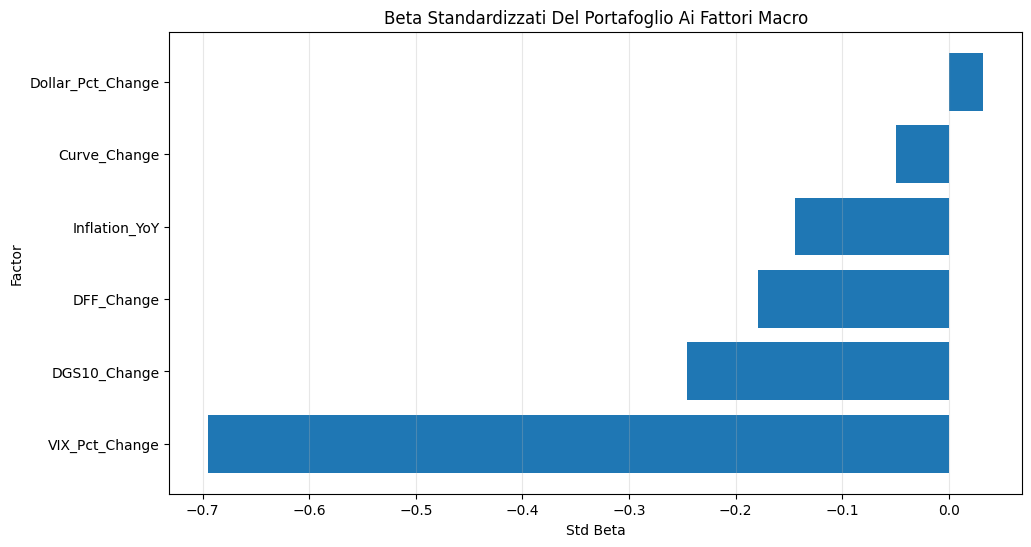

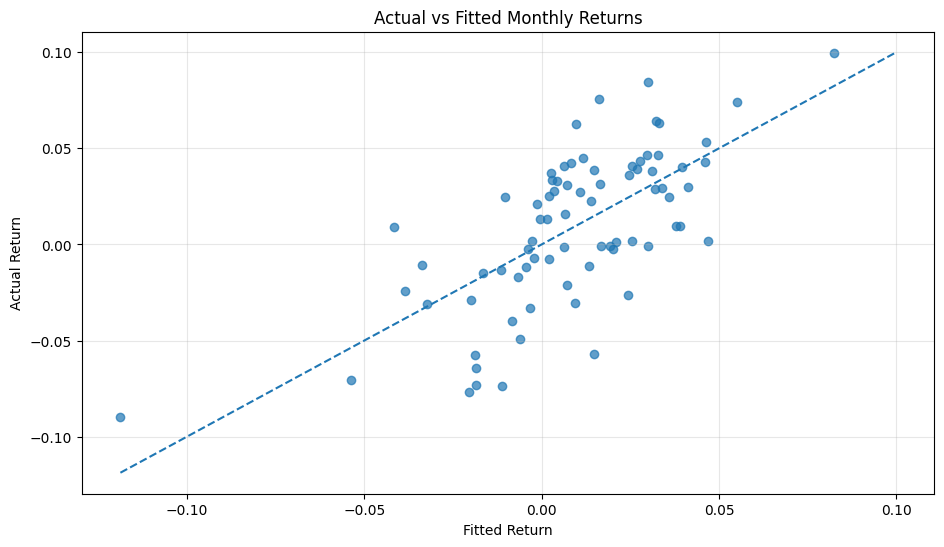

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ============================================================
# 1) CONTROLLO INPUT
# ============================================================

if "analysis_df" not in globals():
    raise ValueError("Manca 'analysis_df'. Esegui prima la cella Portfolio + Macro.")

# ============================================================
# 2) SCELTA FATTORI
#    Uso variabili sensate per una regressione mensile:
#    - cambiamenti tassi
#    - inflazione YoY
#    - variazione % VIX
#    - variazione % Dollar
# ============================================================

factors = [
    "DGS10_Change",        # shock sul 10Y
    "DFF_Change",          # shock Fed
    "Curve_Change",        # variazione curva
    "Inflation_YoY",       # regime inflazione
    "VIX_Pct_Change",      # shock risk sentiment
    "Dollar_Pct_Change"    # forza / debolezza Dollar
]

reg_df = analysis_df[["Portfolio_Return"] + factors].dropna().copy()

if len(reg_df) < 24:
    raise ValueError("Troppi pochi dati utili per una regressione affidabile.")

# ============================================================
# 3) MODELLO RAW
#    Coefficienti in unità originali
#    Uso HAC robust errors per serie temporali mensili
# ============================================================

y = reg_df["Portfolio_Return"]
X = reg_df[factors]
X_const = sm.add_constant(X)

model_raw = sm.OLS(y, X_const).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3}
)

# ============================================================
# 4) MODELLO STANDARDIZZATO
#    Serve per confrontare l'importanza relativa dei fattori
# ============================================================

X_z = (X - X.mean()) / X.std(ddof=0)
y_z = (y - y.mean()) / y.std(ddof=0)

X_z_const = sm.add_constant(X_z)

model_std = sm.OLS(y_z, X_z_const).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3}
)

# ============================================================
# 5) VIF - MULTICOLLINEARITÀ
# ============================================================

vif_df = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values("VIF", ascending=False)

# ============================================================
# 6) TABELLA RISULTATI
# ============================================================

results_table = pd.DataFrame({
    "Factor": factors,
    "Raw_Coeff": model_raw.params[factors].values,
    "Std_Beta": model_std.params[factors].values,
    "t_stat": model_raw.tvalues[factors].values,
    "p_value": model_raw.pvalues[factors].values
})

results_table["Abs_Std_Beta"] = results_table["Std_Beta"].abs()
results_table = results_table.sort_values("Abs_Std_Beta", ascending=False).drop(columns="Abs_Std_Beta")

# Etichette di significatività
def star(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""

results_table["Signif"] = results_table["p_value"].apply(star)

# ============================================================
# 7) FITTED VALUES E RESIDUI
# ============================================================

reg_df["Fitted_Return"] = model_raw.fittedvalues
reg_df["Residual"] = reg_df["Portfolio_Return"] - reg_df["Fitted_Return"]

# ============================================================
# 8) SUMMARY TABLE
# ============================================================

summary_table = pd.DataFrame({
    "Metric": [
        "Observations",
        "R-squared",
        "Adj. R-squared",
        "Mean Actual Monthly Return",
        "Mean Fitted Monthly Return",
        "Residual Std Dev"
    ],
    "Value": [
        int(model_raw.nobs),
        model_raw.rsquared,
        model_raw.rsquared_adj,
        reg_df["Portfolio_Return"].mean(),
        reg_df["Fitted_Return"].mean(),
        reg_df["Residual"].std(ddof=1)
    ]
})

# ============================================================
# 9) FORMATTAZIONE OUTPUT
# ============================================================

results_fmt = results_table.copy()
results_fmt["Raw_Coeff"] = results_fmt["Raw_Coeff"].map(lambda x: f"{x:,.4f}")
results_fmt["Std_Beta"] = results_fmt["Std_Beta"].map(lambda x: f"{x:,.4f}")
results_fmt["t_stat"] = results_fmt["t_stat"].map(lambda x: f"{x:,.3f}")
results_fmt["p_value"] = results_fmt["p_value"].map(lambda x: f"{x:,.4f}")

summary_fmt = summary_table.copy()
summary_fmt["Value"] = summary_fmt["Value"].map(
    lambda x: f"{x:,.4f}" if isinstance(x, (int, float, np.floating)) else x
)

vif_fmt = vif_df.copy()
vif_fmt["VIF"] = vif_fmt["VIF"].map(lambda x: f"{x:,.2f}")

# ============================================================
# 10) STAMPA
# ============================================================

print("\n" + "="*110)
print("FACTOR REGRESSION - PORTAFOGLIO VS MACRO")
print("="*110)
print(summary_fmt)

print("\n" + "="*110)
print("RISULTATI REGRESSIONE")
print("="*110)
print(results_fmt)

print("\n" + "="*110)
print("VIF - MULTICOLLINEARITÀ")
print("="*110)
print(vif_fmt)

print("\n" + "="*110)
print("SUMMARY COMPLETO MODELLO RAW")
print("="*110)
print(model_raw.summary())

# ============================================================
# 11) GRAFICO - BETA STANDARDIZZATI
# ============================================================

plot_beta = results_table.sort_values("Std_Beta")

plt.figure(figsize=(11, 6))
plt.barh(plot_beta["Factor"], plot_beta["Std_Beta"])
plt.title("Beta Standardizzati Del Portafoglio Ai Fattori Macro")
plt.xlabel("Std Beta")
plt.ylabel("Factor")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

# ============================================================
# 12) GRAFICO - ACTUAL VS FITTED
# ============================================================

plt.figure(figsize=(11, 6))
plt.scatter(reg_df["Fitted_Return"], reg_df["Portfolio_Return"], alpha=0.7)
xmin = min(reg_df["Fitted_Return"].min(), reg_df["Portfolio_Return"].min())
xmax = max(reg_df["Fitted_Return"].max(), reg_df["Portfolio_Return"].max())
plt.plot([xmin, xmax], [xmin, xmax], linestyle="--")
plt.title("Actual vs Fitted Monthly Returns")
plt.xlabel("Fitted Return")
plt.ylabel("Actual Return")
plt.grid(True, alpha=0.3)
plt.show()

🔴 VIX_Pct_Change → Std_Beta = -0.57 (molto forte)
👉 Il tuo portafoglio è fortemente negativo al rischio
Tradotto:
Se il mercato entra in stress (VIX ↑)
Il tuo portafoglio scende molto
💡 È tipico di portafogli equity aggressivi
🔴 DFF_Change → Std_Beta = -0.35 (forte)
👉 Sensibile ai tassi FED
Quando i tassi salgono → il tuo portafoglio scende
💡 Tipico di growth / tech / duration lunga



VIX = -0.0631
→ Se VIX cresce di 1 unità → portafoglio perde ~6.3%
⚠️ Ma questo dipende dalla scala → NON è la più importante
Std_Beta (IMPORTANTISSIMO)
👉 Questo è quello che conta davvero
È il coefficiente standardizzato → confrontabile tra fattori
Ti dice:
👉 “quanto impatta questo fattore rispetto agli altri”

VIF = Variance Inflation Factor
Misura:
👉 “quanto una variabile è spiegata dalle altre variabili”
📌 2. COME SI INTERPRETA
Regole standard:
VIF = 1 → perfetto (nessuna correlazione)
VIF 1–3 → ottimo
VIF 3–5 → accettabile
VIF > 5 → problema serio
VIF > 10 → regressione NON affidabile

MIGLIOR COMBINAZIONE (MARKOWITZ + MACRO, NO ORO, AMAZON=5%)
Stock600EU   40.00%
Nasdaq       25.00%
Emergenti    10.00%
SP500        10.00%
Robot        10.00%
Amazon        5.00%

Asset usati nell'ottimizzazione (ORO escluso):
['Nasdaq', 'Emergenti', 'Stock600EU', 'SP500', 'Robot', 'Amazon']

Vincolo fisso applicato: Amazon = 5.00%

Metriche portafoglio scelto:
Mean monthly return   : 0.8478%
Vol monthly           : 4.2799%
Cumulative return     : 78.73%
Max drawdown          : -22.69%
Beta to Fed           : -0.0280
Beta to Inflation     : -0.2387
Macro R^2             : 0.4918
HHI concentration     : 0.2550
Markowitz Exp Return  : 0.8478%
Markowitz Vol         : 4.2799%
Markowitz Sharpe      : 0.1981
Markowitz Utility     : 0.002983
Final score           : 0.7776

Top 10 combinazioni:


,w_Nasdaq,w_Emergenti,w_Stock600EU,w_SP500,w_Robot,w_Amazon,markowitz_exp_return,markowitz_vol,markowitz_sharpe,markowitz_utility,mean_monthly_return,cumulative_return,beta_fed,beta_infl,max_drawdown,hhi,final_score,r2_macro,n_obs
0,25%,10%,40%,10%,10%,5%,0.848%,4.280%,0.1981,0.002983,0.848%,78.73%,-0.0280,-0.2387,-22.69%,0.2550,0.7776,0.4918,77
1,20%,10%,40%,15%,10%,5%,0.831%,4.247%,0.1957,0.002899,0.831%,76.65%,-0.0275,-0.2367,-21.98%,0.2450,0.7765,0.4923,77
2,25%,10%,35%,15%,10%,5%,0.860%,4.317%,0.1991,0.003005,0.860%,80.15%,-0.0292,-0.2428,-23.19%,0.2300,0.7762,0.4950,77
3,20%,10%,35%,20%,10%,5%,0.843%,4.283%,0.1968,0.002927,0.843%,78.07%,-0.0286,-0.2409,-22.48%,0.2250,0.7730,0.4955,77
4,30%,10%,35%,10%,10%,5%,0.876%,4.354%,0.2013,0.003076,0.876%,82.24%,-0.0297,-0.2448,-23.89%,0.2450,0.7714,0.4941,77
5,20%,10%,45%,10%,10%,5%,0.819%,4.216%,0.1943,0.002861,0.819%,75.22%,-0.0263,-0.2326,-21.65%,0.2750,0.7705,0.4887,77
6,25%,10%,30%,20%,10%,5%,0.872%,4.359%,0.2000,0.003017,0.872%,81.56%,-0.0303,-0.2470,-23.69%,0.2150,0.7662,0.4976,77
7,15%,10%,40%,20%,10%,5%,0.815%,4.218%,0.1931,0.002808,0.815%,74.58%,-0.0269,-0.2348,-21.51%,0.2450,0.7662,0.4925,77
8,30%,10%,30%,15%,10%,5%,0.888%,4.397%,0.2020,0.003083,0.888%,83.65%,-0.0308,-0.2489,-24.39%,0.2250,0.7635,0.4968,77
9,15%,10%,35%,25%,10%,5%,0.826%,4.252%,0.1944,0.002841,0.826%,75.99%,-0.0281,-0.2389,-21.77%,0.2300,0.7619,0.4957,77


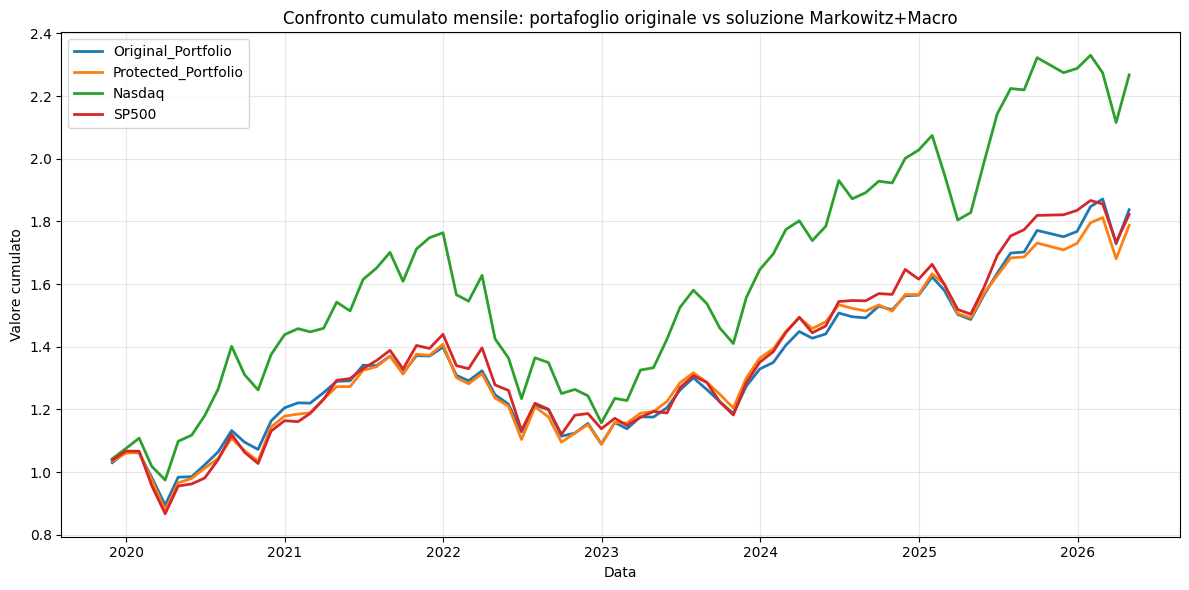

In [11]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# =========================================================
# GRID SEARCH ALLOCAZIONE MACRO-AWARE + MARKOWITZ (NO ORO)
# Vincolo utente: AMAZON peso fisso al 5%
# =========================================================

# -------------------------
# CONTROLLI INPUT BASE


# -------------------------
# PARAMETRI
# -------------------------
STEP = 0.05
MIN_WEIGHT = 0.10
MAX_WEIGHT = 0.60

required_macro_cols = [
    "DFF", "DGS2", "DGS10", "Yield_Curve_10Y_2Y",
    "DFF_Change", "DGS2_Change", "DGS10_Change", "Curve_Change",
    "Inflation_MoM", "Inflation_YoY",
    "VIXCLS", "VIX_Change", "VIX_Pct_Change",
    "DTWEXBGS", "Dollar_Pct_Change"
]

# Vincoli fissi richiesti dall'utente
FIXED_WEIGHTS_REQUEST = {
    "amazon": 0.05,
}

# Pesi del punteggio ibrido (Markowitz + Macro)
W_MARKOWITZ_UTILITY = 0.35
W_MARKOWITZ_SHARPE = 0.15
W_FED = 0.20
W_INFL = 0.15
W_CONC = 0.10
W_DD = 0.05

# Avversione al rischio Markowitz (sulla varianza)
LAMBDA_RISK = 3.0

# -------------------------
# HELPER
# -------------------------
def sanitize_return_series(s: pd.Series) -> pd.Series:
    s = pd.Series(s).copy()
    s.index = pd.to_datetime(s.index, errors="coerce")
    s = s[~s.index.isna()].sort_index()
    s = pd.to_numeric(s, errors="coerce").dropna()

    if s.empty:
        return s

    if (s.abs().median() > 0.2) or (s.abs().quantile(0.95) > 1.0):
        s = s / 100.0

    s = s[s > -0.999]
    return s

def to_monthly_returns(s: pd.Series) -> pd.Series:
    s = sanitize_return_series(s)
    return (1 + s).resample("ME").prod() - 1

def max_drawdown_from_returns(x: pd.Series) -> float:
    x = pd.Series(x).dropna()
    if x.empty:
        return np.nan
    eq = (1 + x).cumprod()
    dd = eq / eq.cummax() - 1
    return float(dd.min())

def minmax_score(series: pd.Series, higher_is_better=True) -> pd.Series:
    s = pd.Series(series, dtype=float).copy().replace([np.inf, -np.inf], np.nan)
    valid = s.dropna()

    if valid.empty:
        base = pd.Series(0.5, index=s.index)
    else:
        smin, smax = valid.min(), valid.max()
        if np.isclose(smax - smin, 0):
            base = pd.Series(0.5, index=s.index)
        else:
            base = (s - smin) / (smax - smin)
            base = base.fillna(0.5)

    return base if higher_is_better else (1 - base)

def build_fixed_weight_map(asset_names, fixed_request):
    """
    Mappa i nomi richiesti (case-insensitive) ai nomi reali in asset_names.
    """
    fixed_real = {}
    lower_to_real = {a.strip().lower(): a for a in asset_names}

    for req_name, req_w in fixed_request.items():
        key = req_name.strip().lower()
        if key not in lower_to_real:
            raise ValueError(f"Asset fisso richiesto non trovato nell'universo: {req_name}")
        fixed_real[lower_to_real[key]] = float(req_w)

    return fixed_real

def generate_weight_grid_with_fixed(asset_names, step, min_w, max_w, fixed_weights_real):
    """
    Genera griglia pesi con:
    - somma = 1
    - bounds min/max sui soli asset non fissi
    - pesi fissati per gli asset in fixed_weights_real
    """
    units = int(round(1 / step))

    fixed_units = {a: int(round(w / step)) for a, w in fixed_weights_real.items()}
    fixed_sum_units = sum(fixed_units.values())
    remaining_units = units - fixed_sum_units

    free_assets = [a for a in asset_names if a not in fixed_units]

    if remaining_units < 0:
        raise ValueError("Somma dei pesi fissi > 100%.")

    min_u = int(round(min_w / step))
    max_u = int(round(max_w / step))

    if len(free_assets) == 0:
        if remaining_units != 0:
            raise ValueError("Con soli pesi fissi la somma non è 100%.")
        w_full = np.array([fixed_units[a] / units for a in asset_names], dtype=float)
        return np.array([w_full])

    if remaining_units < len(free_assets) * min_u or remaining_units > len(free_assets) * max_u:
        raise ValueError(
            "Vincoli non fattibili con pesi fissi: "
            f"remaining={remaining_units/units:.2%}, free_assets={len(free_assets)}"
        )

    combos = []

    def rec(idx, rem_units, current_units):
        assets_left = len(free_assets) - idx
        if assets_left == 1:
            if min_u <= rem_units <= max_u:
                combos.append(current_units + [rem_units])
            return

        low = max(min_u, rem_units - max_u * (assets_left - 1))
        high = min(max_u, rem_units - min_u * (assets_left - 1))

        for u in range(low, high + 1):
            rec(idx + 1, rem_units - u, current_units + [u])

    rec(0, remaining_units, [])

    full_weight_vectors = []
    for combo in combos:
        free_map = {a: combo[i] / units for i, a in enumerate(free_assets)}
        w = []
        for a in asset_names:
            if a in fixed_units:
                w.append(fixed_units[a] / units)
            else:
                w.append(free_map[a])
        full_weight_vectors.append(w)

    return np.array(full_weight_vectors, dtype=float)

# -------------------------
# 1) UNIVERSO ASSET OTTIMIZZABILI (NO ORO)
# -------------------------
asset_series = {}

if "returns_df" in globals():
    tmp_df = returns_df.copy()

    if "Date" in tmp_df.columns:
        tmp_df["Date"] = pd.to_datetime(tmp_df["Date"], errors="coerce")
        tmp_df = tmp_df.set_index("Date")

    tmp_df.index = pd.to_datetime(tmp_df.index, errors="coerce")
    tmp_df = tmp_df[~tmp_df.index.isna()].sort_index()

    excluded_cols = {"Portfolio_Return", "Portfolio", "portfolio", "portfolioreturn"}
    excluded_assets = {"oro", "gold"}

    candidate_cols = [
        c for c in tmp_df.columns
        if str(c) not in excluded_cols and str(c).strip().lower() not in excluded_assets
    ]

    if "files" in globals() and isinstance(files, dict):
        ordered_cols = [k for k in files.keys() if k in candidate_cols]
        remaining_cols = [c for c in candidate_cols if c not in ordered_cols]
        candidate_cols = ordered_cols + remaining_cols

    for c in candidate_cols:
        s = pd.to_numeric(tmp_df[c], errors="coerce")
        if s.notna().sum() > 10:
            asset_series[str(c)] = s

if len(asset_series) == 0:
    asset_series = {
        "Portfolio": pd.Series(returns_df["Portfolio_Return"]).copy(),
        "Nasdaq": pd.Series(returns_df["Nasdaq"]).copy(),
        "SP500": pd.Series(returns_df["SP500"]).copy(),
    }

monthly_assets_dict = {}
for name, s in asset_series.items():
    m = to_monthly_returns(s)
    if m.notna().sum() >= 24:
        monthly_assets_dict[name] = m.rename(name)

if len(monthly_assets_dict) < 2:
    raise ValueError("Troppi pochi asset validi dopo la conversione mensile.")

investment_returns = pd.concat(monthly_assets_dict.values(), axis=1, join="inner").dropna(how="any")
asset_cols = investment_returns.columns.tolist()
n_assets = len(asset_cols)

# Mappa pesi fissi richiesti dall'utente ai nomi reali colonna
fixed_weights_real = build_fixed_weight_map(asset_cols, FIXED_WEIGHTS_REQUEST)

# -------------------------
# 2) FATTORI MACRO MENSILI
# -------------------------
macro = analysis_df.copy()
macro.index = pd.to_datetime(macro.index, errors="coerce")
macro = macro[~macro.index.isna()].sort_index()
macro = macro[required_macro_cols].apply(pd.to_numeric, errors="coerce")
macro = macro.resample("ME").last().dropna(how="any")

# -------------------------
# 3) DATASET FINALE ALLINEATO
# -------------------------
dataset = pd.concat([investment_returns, macro], axis=1, join="inner").dropna(how="any")
dataset = dataset[~dataset.index.duplicated(keep="last")].sort_index()

if dataset.shape[0] < 24:
    raise ValueError(
        f"Troppo poche osservazioni mensili comuni dopo l'allineamento: {dataset.shape[0]}. "
        "Servono almeno ~24 mesi per una lettura sensata."
    )

# Statistiche Markowitz (attese campionarie)
mu = dataset[asset_cols].mean().to_numpy(dtype=float)
Sigma = dataset[asset_cols].cov().to_numpy(dtype=float)
Sigma = Sigma + np.eye(len(asset_cols)) * 1e-8  # stabilizzazione numerica

# -------------------------
# 4) GRID SEARCH CON VINCOLO AMAZON=5%
# -------------------------
weight_grid = generate_weight_grid_with_fixed(
    asset_names=asset_cols,
    step=STEP,
    min_w=MIN_WEIGHT,
    max_w=MAX_WEIGHT,
    fixed_weights_real=fixed_weights_real,
)

if len(weight_grid) == 0:
    raise ValueError("Nessuna combinazione di pesi fattibile con i vincoli scelti.")

results = []

for w in weight_grid:
    # Rendimento storico realizzato del portafoglio candidato
    port_ret = dataset[asset_cols].to_numpy(dtype=float) @ w
    y = pd.Series(port_ret, index=dataset.index, name="Candidate_Portfolio")

    # Regressione macro
    X = dataset[required_macro_cols].copy()
    reg_data = pd.concat([y, X], axis=1).dropna(how="any")

    if reg_data.shape[0] < 12:
        continue
    if reg_data["DFF_Change"].std(ddof=0) == 0 or reg_data["Inflation_YoY"].std(ddof=0) == 0:
        continue

    y_reg = reg_data["Candidate_Portfolio"]
    X_reg = sm.add_constant(reg_data[required_macro_cols], has_constant="add")

    try:
        model = sm.OLS(y_reg, X_reg).fit()
    except Exception:
        continue

    beta_fed = float(model.params.get("DFF_Change", np.nan))
    beta_infl = float(model.params.get("Inflation_YoY", np.nan))

    # Metriche realizzate
    mean_monthly_return = float(y_reg.mean())
    vol_monthly = float(y_reg.std(ddof=1))
    cumulative_return = float((1 + y_reg).prod() - 1)
    max_dd = float(max_drawdown_from_returns(y_reg))
    hhi = float(np.sum(np.square(w)))

    # Metriche Markowitz (attese)
    markowitz_exp_return = float(np.dot(w, mu))
    markowitz_var = float(np.dot(w, Sigma @ w))
    markowitz_vol = float(np.sqrt(max(markowitz_var, 0.0)))
    markowitz_sharpe = float(markowitz_exp_return / markowitz_vol) if markowitz_vol > 0 else np.nan
    markowitz_utility = float(markowitz_exp_return - LAMBDA_RISK * markowitz_var)

    row = {
        "mean_monthly_return": mean_monthly_return,
        "vol_monthly": vol_monthly,
        "cumulative_return": cumulative_return,
        "max_drawdown": max_dd,
        "beta_fed": beta_fed,
        "beta_infl": beta_infl,
        "abs_beta_fed": abs(beta_fed),
        "abs_beta_infl": abs(beta_infl),
        "hhi": hhi,
        "r2_macro": float(model.rsquared),
        "n_obs": int(reg_data.shape[0]),
        "markowitz_exp_return": markowitz_exp_return,
        "markowitz_vol": markowitz_vol,
        "markowitz_var": markowitz_var,
        "markowitz_sharpe": markowitz_sharpe,
        "markowitz_utility": markowitz_utility,
    }
    for i, a in enumerate(asset_cols):
        row[f"w_{a}"] = float(w[i])

    results.append(row)

grid_results_df = pd.DataFrame(results)
if grid_results_df.empty:
    raise ValueError("Nessuna combinazione valida: verifica dati, NaN e variabilità dei fattori macro.")

# -------------------------
# 5) SCORE IBRIDO: MARKOWITZ + MACRO
# -------------------------
grid_results_df["score_mk_utility"] = minmax_score(grid_results_df["markowitz_utility"], higher_is_better=True)
grid_results_df["score_mk_sharpe"] = minmax_score(grid_results_df["markowitz_sharpe"], higher_is_better=True)
grid_results_df["score_fed"] = minmax_score(grid_results_df["abs_beta_fed"], higher_is_better=False)
grid_results_df["score_infl"] = minmax_score(grid_results_df["abs_beta_infl"], higher_is_better=False)
grid_results_df["score_conc"] = minmax_score(grid_results_df["hhi"], higher_is_better=False)
grid_results_df["score_dd"] = minmax_score(grid_results_df["max_drawdown"].abs(), higher_is_better=False)

grid_results_df["final_score"] = (
    W_MARKOWITZ_UTILITY * grid_results_df["score_mk_utility"] +
    W_MARKOWITZ_SHARPE * grid_results_df["score_mk_sharpe"] +
    W_FED * grid_results_df["score_fed"] +
    W_INFL * grid_results_df["score_infl"] +
    W_CONC * grid_results_df["score_conc"] +
    W_DD * grid_results_df["score_dd"]
)

grid_results_df = grid_results_df.sort_values(
    ["final_score", "markowitz_utility", "mean_monthly_return"],
    ascending=[False, False, False]
).reset_index(drop=True)

best_grid_row = grid_results_df.iloc[0].copy()
weight_cols = [f"w_{a}" for a in asset_cols]
best_weights = best_grid_row[weight_cols].copy()
best_weights.index = asset_cols

# Check vincolo AMAZON=5%
amazon_real_name = next(a for a in fixed_weights_real.keys())
if not np.isclose(best_weights[amazon_real_name], fixed_weights_real[amazon_real_name]):
    raise RuntimeError("Vincolo AMAZON=5% non rispettato: controllare generazione griglia.")

protected_portfolio_monthly = (
    dataset[asset_cols].to_numpy(dtype=float) @ best_weights.values
)
protected_portfolio_monthly = pd.Series(
    protected_portfolio_monthly,
    index=dataset.index,
    name="Protected_Portfolio"
)

# -------------------------
# 6) OUTPUT
# -------------------------
print("=" * 110)
print("MIGLIOR COMBINAZIONE (MARKOWITZ + MACRO, NO ORO, AMAZON=5%)")
print("=" * 110)
print(best_weights.sort_values(ascending=False).to_string(float_format=lambda x: f"{x:.2%}"))

print("\nAsset usati nell'ottimizzazione (ORO escluso):")
print(asset_cols)
print(f"\nVincolo fisso applicato: {amazon_real_name} = {fixed_weights_real[amazon_real_name]:.2%}")

print("\nMetriche portafoglio scelto:")
print(f"Mean monthly return   : {best_grid_row['mean_monthly_return']:.4%}")
print(f"Vol monthly           : {best_grid_row['vol_monthly']:.4%}")
print(f"Cumulative return     : {best_grid_row['cumulative_return']:.2%}")
print(f"Max drawdown          : {best_grid_row['max_drawdown']:.2%}")
print(f"Beta to Fed           : {best_grid_row['beta_fed']:.4f}")
print(f"Beta to Inflation     : {best_grid_row['beta_infl']:.4f}")
print(f"Macro R^2             : {best_grid_row['r2_macro']:.4f}")
print(f"HHI concentration     : {best_grid_row['hhi']:.4f}")
print(f"Markowitz Exp Return  : {best_grid_row['markowitz_exp_return']:.4%}")
print(f"Markowitz Vol         : {best_grid_row['markowitz_vol']:.4%}")
print(f"Markowitz Sharpe      : {best_grid_row['markowitz_sharpe']:.4f}")
print(f"Markowitz Utility     : {best_grid_row['markowitz_utility']:.6f}")
print(f"Final score           : {best_grid_row['final_score']:.4f}")

print("\nTop 10 combinazioni:")
show_cols = weight_cols + [
    "markowitz_exp_return", "markowitz_vol", "markowitz_sharpe", "markowitz_utility",
    "mean_monthly_return", "cumulative_return",
    "beta_fed", "beta_infl", "max_drawdown", "hhi", "final_score", "r2_macro", "n_obs"
]
fmt_dict = {c: "{:.0%}" for c in weight_cols}
fmt_dict.update({
    "markowitz_exp_return": "{:.3%}",
    "markowitz_vol": "{:.3%}",
    "markowitz_sharpe": "{:.4f}",
    "markowitz_utility": "{:.6f}",
    "mean_monthly_return": "{:.3%}",
    "cumulative_return": "{:.2%}",
    "beta_fed": "{:.4f}",
    "beta_infl": "{:.4f}",
    "max_drawdown": "{:.2%}",
    "hhi": "{:.4f}",
    "final_score": "{:.4f}",
    "r2_macro": "{:.4f}",
    "n_obs": "{:d}",
})

display(grid_results_df[show_cols].head(10).style.format(fmt_dict))

# -------------------------
# 7) GRAFICO CUMULATO VS BENCHMARK
# -------------------------
portfolio_m = to_monthly_returns(returns_df["Portfolio_Return"]).rename("Original_Portfolio")
nasdaq_m = to_monthly_returns(returns_df["Nasdaq"]).rename("Nasdaq")
sp500_m = to_monthly_returns(returns_df["SP500"]).rename("SP500")

comparison_monthly = pd.concat([
    portfolio_m,
    protected_portfolio_monthly,
    nasdaq_m,
    sp500_m,
], axis=1).dropna(how="any")

comparison_cum = (1 + comparison_monthly).cumprod()

plt.figure(figsize=(12, 6))
for c in comparison_cum.columns:
    plt.plot(comparison_cum.index, comparison_cum[c], linewidth=2, label=c)

plt.title("Confronto cumulato mensile: portafoglio originale vs soluzione Markowitz+Macro")
plt.xlabel("Data")
plt.ylabel("Valore cumulato")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

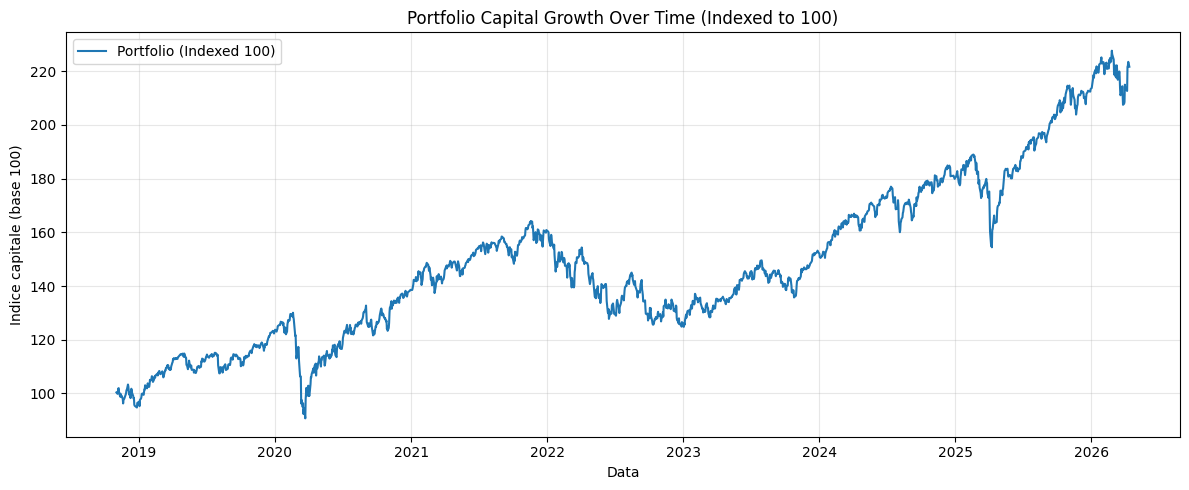

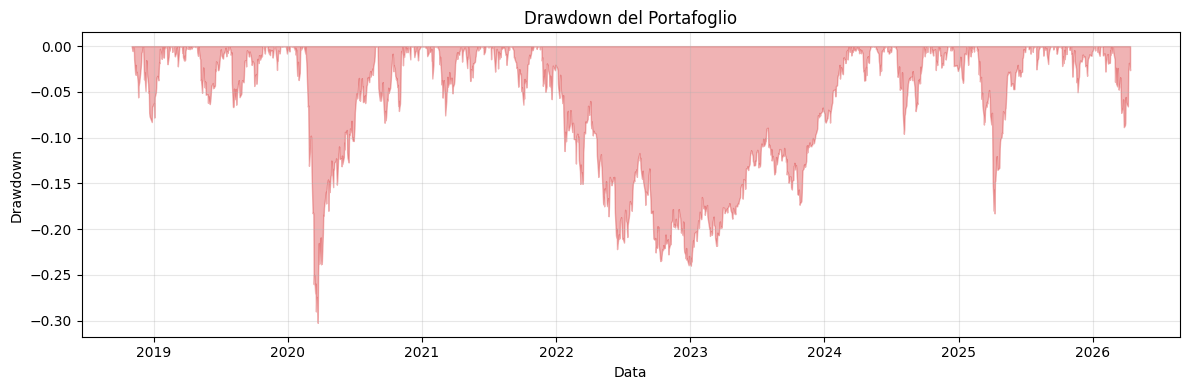

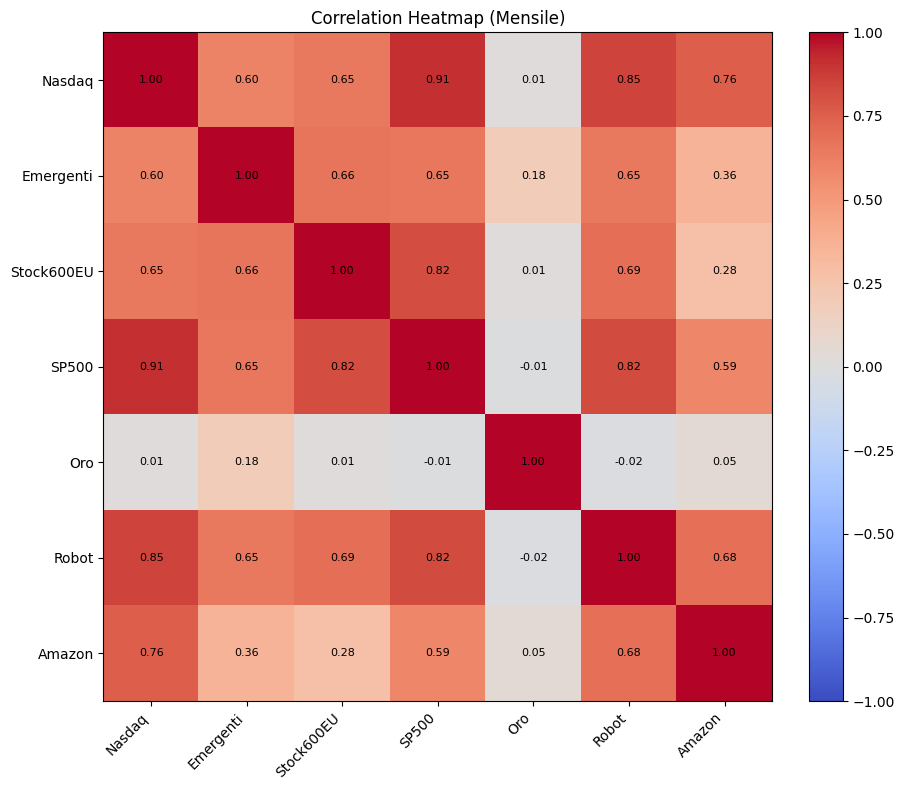

In [13]:
# ==============================================================================================================
# 8) PORTFOLIO CAPITAL GROWTH + DRAWDOWN + CORRELATION HEATMAP (MENSILE)
# ==============================================================================================================

# --- Capital growth (indexed to 100) ---
if "port_daily" in globals() and isinstance(port_daily, pd.Series):
    capital_returns = port_daily.copy()
elif "returns_df" in globals() and isinstance(returns_df, pd.DataFrame):
    tmp_port = returns_df.copy()
    if "Date" in tmp_port.columns:
        tmp_port["Date"] = pd.to_datetime(tmp_port["Date"], errors="coerce")
        tmp_port = tmp_port.set_index("Date")
    tmp_port.index = pd.to_datetime(tmp_port.index, errors="coerce")
    tmp_port = tmp_port[~tmp_port.index.isna()].sort_index()
    if "Portfolio_Return" in tmp_port.columns:
        capital_returns = pd.to_numeric(tmp_port["Portfolio_Return"], errors="coerce")
    else:
        raise ValueError("Colonna 'Portfolio_Return' non trovata per il calcolo del capitale.")
else:
    raise ValueError("Manca 'returns_df' o 'port_daily' per il calcolo del capitale.")

capital_returns = sanitize_return_series(capital_returns)
capital_index = (1 + capital_returns).cumprod() * 100

plt.figure(figsize=(12, 5))
plt.plot(capital_index.index, capital_index.values, label="Portfolio (Indexed 100)", color="tab:blue")
plt.title("Portfolio Capital Growth Over Time (Indexed to 100)")
plt.ylabel("Indice capitale (base 100)")
plt.xlabel("Data")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Drawdown ---
rolling_peak = capital_index.cummax()
drawdown_series = capital_index / rolling_peak - 1

plt.figure(figsize=(12, 4))
plt.fill_between(drawdown_series.index, drawdown_series.values, color="tab:red", alpha=0.35)
plt.title("Drawdown del Portafoglio")
plt.ylabel("Drawdown")
plt.xlabel("Data")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Correlation heatmap (monthly) ---
if "returns_df" not in globals():
    raise ValueError("Manca 'returns_df' per la correlation mensile.")

tmp_corr = returns_df.copy()
if "Date" in tmp_corr.columns:
    tmp_corr["Date"] = pd.to_datetime(tmp_corr["Date"], errors="coerce")
    tmp_corr = tmp_corr.set_index("Date")

tmp_corr.index = pd.to_datetime(tmp_corr.index, errors="coerce")
tmp_corr = tmp_corr[~tmp_corr.index.isna()].sort_index()

if "files" in globals() and isinstance(files, dict):
    corr_cols = [c for c in files.keys() if c in tmp_corr.columns]
else:
    corr_cols = [c for c in tmp_corr.columns if str(c).lower() not in {"portfolio_return", "portfolio"}]

if len(corr_cols) < 2:
    raise ValueError("Troppi pochi asset per la heatmap di correlazione.")

monthly_base = pd.DataFrame({
    c: to_monthly_returns(pd.to_numeric(tmp_corr[c], errors="coerce"))
    for c in corr_cols
})

monthly_base = monthly_base.dropna(how="any")
monthly_corr = monthly_base.corr()

fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(monthly_corr.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(monthly_corr.columns)))
ax.set_yticks(range(len(monthly_corr.index)))
ax.set_xticklabels(monthly_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(monthly_corr.index)

for i in range(len(monthly_corr.index)):
    for j in range(len(monthly_corr.columns)):
        ax.text(j, i, f"{monthly_corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation Heatmap (Mensile)")
fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()